# CURB - Enforcement Prioritizer
### notebook 02 - Problem Statement 1 (Parking-Induced Congestion)

Turns the ranked hotspots into a **control-room-facing priority list** and emits
frontend-ready files (`outputs/curb_priorities.json` + `.csv`).

**Honest framing (read once):**
- `congestion_impact_index` is the severity x footprint score **normalised to
  0-100** - an INDEX, not a measured or predicted % traffic change. There is no
  congestion measurement in this dataset.
- We do **not** assume how many units are available. Each spot is described by
  its **own measured enforcement history**; deployment is the control room's call.
- Nothing about the force is hardcoded. Citywide staffing is shown as a
  day-by-day **spread** (descriptive context), never used as a fixed capacity.

Per spot, the list stays simple - rank, impact index, a **Chronic / Frequent /
Occasional** tag, cause -> fix, one deploy note - while richer fields stay in the
data for the frontend.

In [1]:
# --- setup ---
import os, sys, json
from pathlib import Path
REPO_ROOT = Path.cwd()
if not (REPO_ROOT / "config.py").exists() and (REPO_ROOT.parent / "config.py").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT)); os.chdir(REPO_ROOT)

import config, pandas as pd, matplotlib.pyplot as plt
from src.pipeline import run as run_pipeline
from src.prioritizer import prioritize, export, citywide_context
DATA_PATH = config.DATA_PATH
pd.set_option("display.max_colwidth", 38)
print("data:", DATA_PATH, "exists:", os.path.exists(DATA_PATH))

data: data/violations.csv exists: True


## 1 - Build hotspots, then prioritize

In [2]:
hot = run_pipeline(DATA_PATH, write=False)        # cluster + impact + root cause
context = citywide_context(DATA_PATH)             # descriptive staffing spread
prio = prioritize(hot, DATA_PATH)                 # add index + persistence + notes
print(f"{len(prio):,} prioritized hotspots")

[data] loaded 298,450 rows -> 248,376 usable after cleaning
[hotspots] 13,782 candidate cells built
[rootcause] labelled — distribution:
             6,040  Enforcement priority
             3,288  Commuter overflow
             2,334  Delivery overflow
             1,956  Hire / transit demand
               162  Safety risk
                 2  Structural demand
13,782 prioritized hotspots


## 2 - The clean list view (what an officer reads)

In [3]:
prio.head(15)[["rank", "name", "congestion_impact_index",
               "persistence_tier", "root_cause", "deploy_note"]]

,rank,name,congestion_impact_index,persistence_tier,root_cause,deploy_note
0,1,"Kadubeesanahalli Underpass, Kadub...",100.0,Frequent,Enforcement priority,Recurring - schedule periodic sweeps.
1,2,BTP051 - Safina Plaza Junction,91.3,Chronic,Hire / transit demand,Standing post - assign a unit on a...
2,3,"Kadubeesanahalli Underpass, Kadub...",76.9,Frequent,Enforcement priority,Recurring - schedule periodic sweeps.
3,4,"MBT Road, Tin Factory Junction",76.3,Chronic,Safety risk,Standing post - assign a unit on a...
4,5,BTP211 - Central Street Junction,68.9,Chronic,Hire / transit demand,Standing post - assign a unit on a...
5,6,"New Horizon College Road, New Hor...",57.2,Chronic,Commuter overflow,Standing post - assign a unit on a...
6,7,"Outer Ring Road, Venkatappa Colony",54.9,Chronic,Hire / transit demand,Standing post - assign a unit on a...
7,8,"Unnamed Road, Begur Chikkanahalli",51.6,Chronic,Hire / transit demand,Standing post - assign a unit on a...
8,9,"Old Madras Road, Royal Heritage",50.2,Chronic,Enforcement priority,Standing post - assign a unit on a...
9,10,"Bellary Road, Vinayaka Nagar",48.7,Chronic,Commuter overflow,Standing post - assign a unit on a...


## 3 - The full field set (what the frontend receives)

In [4]:
from src.prioritizer import FRONTEND_FIELDS
prio.head(8)[[c for c in FRONTEND_FIELDS if c in prio.columns]]

,rank,name,clat,clon,congestion_impact_index,persistence_tier,recurrence_days,window_days,units_typical,units_peak,root_cause,recommended_fix,deploy_note,violations,impact_score,cumulative_coverage_pct
0,1,"Kadubeesanahalli Underpass, Kadub...",12.9400,77.6955,100.0,Frequent,23,150,1,2,Enforcement priority,Ranked patrol dispatch,Recurring - schedule periodic sweeps.,589,2997.54,0.8
1,2,BTP051 - Safina Plaza Junction,12.9810,77.6100,91.3,Chronic,133,150,2,7,Hire / transit demand,Designated auto/cab stand + drop-o...,Standing post - assign a unit on a...,1885,2735.50,1.5
2,3,"Kadubeesanahalli Underpass, Kadub...",12.9395,77.6955,76.9,Frequent,47,150,1,2,Enforcement priority,Ranked patrol dispatch,Recurring - schedule periodic sweeps.,511,2305.32,2.1
3,4,"MBT Road, Tin Factory Junction",12.9965,77.6690,76.3,Chronic,86,150,1,3,Safety risk,Bollards / physical barrier + enfo...,Standing post - assign a unit on a...,353,2288.16,2.7
4,5,BTP211 - Central Street Junction,12.9840,77.6035,68.9,Chronic,125,150,2,8,Hire / transit demand,Designated auto/cab stand + drop-o...,Standing post - assign a unit on a...,1631,2066.75,3.3
5,6,"New Horizon College Road, New Hor...",12.9335,77.6910,57.2,Chronic,72,150,1,6,Commuter overflow,Park-and-ride signage + reroute to...,Standing post - assign a unit on a...,1685,1714.47,3.7
6,7,"Outer Ring Road, Venkatappa Colony",13.0005,77.6775,54.9,Chronic,76,150,1,2,Hire / transit demand,Designated auto/cab stand + drop-o...,Standing post - assign a unit on a...,489,1644.91,4.2
7,8,"Unnamed Road, Begur Chikkanahalli",13.1840,77.6795,51.6,Chronic,104,150,1,4,Hire / transit demand,Designated auto/cab stand + drop-o...,Standing post - assign a unit on a...,503,1547.38,4.6


## 4 - Persistence triage + impact-coverage curve

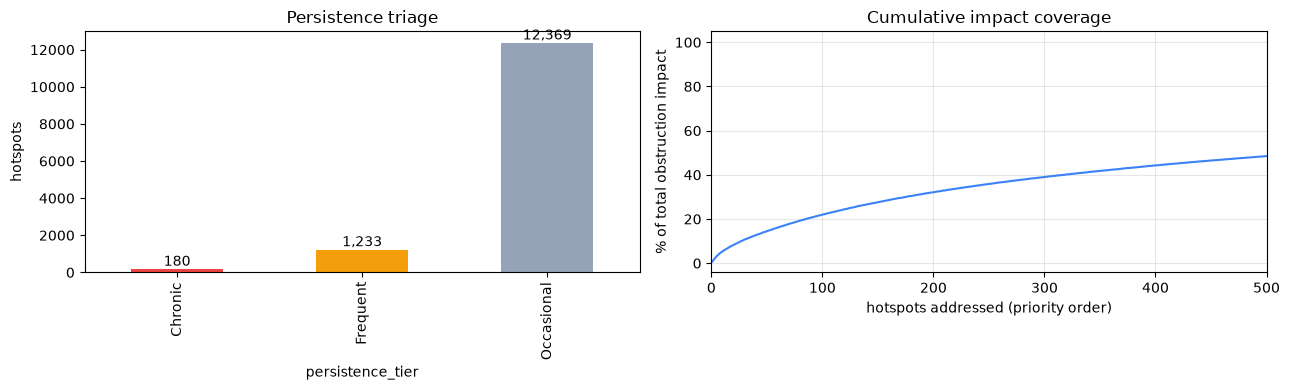

top  50 spots -> 14.5% of total obstruction impact
top 100 spots -> 22.0% of total obstruction impact
top 250 spots -> 35.9% of total obstruction impact


In [5]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

order = ["Chronic", "Frequent", "Occasional"]
prio["persistence_tier"].value_counts().reindex(order).plot.bar(
    ax=ax[0], color=["#ef4444", "#f59e0b", "#94a3b8"])
ax[0].set_title("Persistence triage"); ax[0].set_ylabel("hotspots")
for i, v in enumerate(prio["persistence_tier"].value_counts().reindex(order)):
    ax[0].text(i, v, f"{v:,}", ha="center", va="bottom")

ax[1].plot(range(1, len(prio) + 1), prio["cumulative_coverage_pct"], color="#3b82f6")
ax[1].set_xlim(0, 500); ax[1].set_xlabel("hotspots addressed (priority order)")
ax[1].set_ylabel("% of total obstruction impact")
ax[1].set_title("Cumulative impact coverage"); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()

for n in (50, 100, 250):
    print(f"top {n:>3} spots -> {prio.iloc[n-1]['cumulative_coverage_pct']}% of total obstruction impact")

## 5 - Priority view per root cause\nThe *fix* differs by cause, so a planner can filter to the lever they control.

In [6]:
for cause in ["Delivery overflow", "Safety risk", "Commuter overflow", "Hire / transit demand"]:
    sub = prio[prio.root_cause == cause].head(3)
    if len(sub):
        print(f"\n### {cause}  ->  {sub.iloc[0]['recommended_fix']}")
        print(sub[["rank", "name", "congestion_impact_index", "persistence_tier"]].to_string(index=False))


### Delivery overflow  ->  Timed loading bay (off-peak windows)
 rank                                                   name  congestion_impact_index persistence_tier
   59                   BTP083 - AS Char Street, Mysore Road                     20.7          Chronic
   82                         MBT Road,  Devasandra Junction                     18.3          Chronic
   84 Dr Rajkumar Puniya Bhoomi Road,  Narasimhaswamy Layout                     18.1         Frequent

### Safety risk  ->  Bollards / physical barrier + enforcement
 rank                                                          name  congestion_impact_index persistence_tier
    4                               MBT Road,  Tin Factory Junction                     76.3          Chronic
   13 New Horizon College Road,  New Horizon College of Engineering                     38.1          Chronic
   22               New Horizon College Road,  Embassy Tech Village                     31.6         Frequent

### Commuter overf

## 6 - Citywide staffing context (descriptive only)
Shown as a **day-by-day spread**, not a single number - daily staffing varies and
is never used as an input to the ranking.

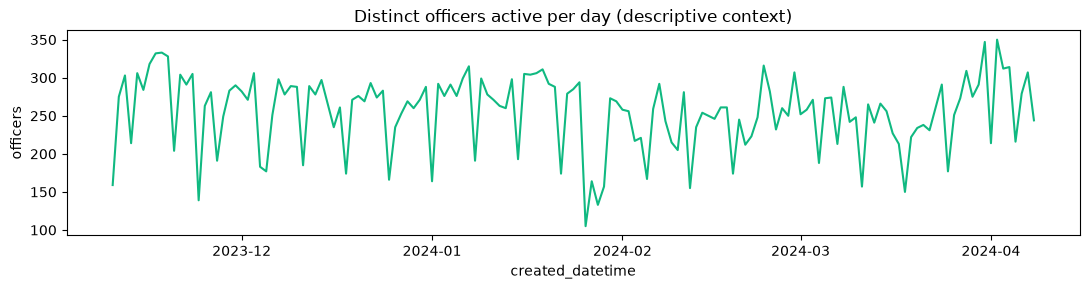

{
  "officers_per_day_min": 105,
  "officers_per_day_p25": 231,
  "officers_per_day_median": 266,
  "officers_per_day_p75": 289,
  "officers_per_day_max": 350,
  "active_days_in_data": 151,
  "note": "Descriptive only; recomputed from the loaded data. Daily staffing varies - shown as a spread, never used as a fixed capacity."
}


In [7]:
# day-by-day distinct officers (force-on-street), straight from the data
src_cols = ["latitude", "longitude", "created_by_id", "created_datetime", "validation_status"]
d = pd.read_csv(DATA_PATH, usecols=src_cols)
d = d[~d.validation_status.isin(config.DROP_VALIDATION)].dropna(subset=["latitude", "longitude"])
b = config.BBOX
d = d[d.latitude.between(b["lat_min"], b["lat_max"]) & d.longitude.between(b["lon_min"], b["lon_max"])]
day = pd.to_datetime(d.created_datetime, errors="coerce", utc=True).dt.tz_convert("Asia/Kolkata").dt.date
opd = d.groupby(day).created_by_id.nunique()

opd.plot(figsize=(11, 3), color="#10b981")
plt.title("Distinct officers active per day (descriptive context)")
plt.ylabel("officers"); plt.tight_layout(); plt.show()
print(json.dumps(context, indent=2))

## 7 - Export for the frontend

In [ ]:
csv_path, json_path = export(prio, context)
print("wrote:", csv_path)
print("wrote:", json_path)

# peek at one frontend record
sample = json.load(open(json_path))
print("\nmeta:", json.dumps(sample["meta"], indent=2))
print("\nfirst hotspot record:")
print(json.dumps(sample["hotspots"][1], indent=2))

wrote: outputs\curb_priorities.csv
wrote: outputs\curb_priorities.json

meta: {
  "hotspot_count": 13782,
  "json_top_n": 500,
  "note": "congestion_impact_index is a normalised severity x footprint INDEX (0-100), not a measured/predicted traffic change."
}

first hotspot record:
{
  "rank": 2,
  "name": "BTP051 - Safina Plaza Junction",
  "lat": 12.981,
  "lon": 77.61,
  "congestion_impact_index": 91.3,
  "persistence_tier": "Chronic",
  "recurrence_days": 133,
  "window_days": 150,
  "units_typical": 2,
  "units_peak": 7,
  "root_cause": "Hire / transit demand",
  "recommended_fix": "Designated auto/cab stand + drop-off zone",
  "deploy_note": "Standing post - assign a unit on a regular basis.",
  "violations": 1885,
  "impact_score": 2735.5,
  "cumulative_coverage_pct": 1.5
}


: 

## Methodology note (for the deck / when a judge asks)
- **Ranking** is by an obstruction-impact index (severity x vehicle footprint),
  not measured traffic delay. We claim *priority*, never a traffic-% outcome.
- **Persistence** (Chronic/Frequent/Occasional) is measured from each spot's own
  active-day history in the data - the one operational signal the data supports
  cleanly. Thresholds are documented constants in `src/prioritizer.py`.
- **No assumed force size.** `units_typical`/`units_peak` are each spot's measured
  history; citywide staffing is descriptive context only.
- Everything recomputes from whatever data is loaded; nothing is hardcoded except
  the documented severity/footprint/persistence constants.